<a href="https://colab.research.google.com/github/Sky-lark27/MARL-Framework/blob/main/HeterogenousMARLFrameworkForDisasterEvacuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VERSION 1 -STATIC HAZARDS- BASELINE


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

class HeteroDisasterEnv:
    def __init__(self,
                 grid_size=10,
                 n_responders=1,
                 n_vehicles=1,
                 n_civilians=5,
                 max_steps=200):

        self.grid_size = grid_size
        self.n_responders = n_responders
        self.n_vehicles = n_vehicles
        self.n_agents = n_responders + n_vehicles
        self.n_civilians = n_civilians
        self.max_steps = max_steps

        # agent type list (order matters)
        self.agent_types = (
            ["responder"] * n_responders +
            ["vehicle"] * n_vehicles
        )

        self.reset()

    # ---------------- RESET ----------------
    def reset(self):
        self.steps = 0
        self.grid = np.zeros((self.grid_size, self.grid_size))

        # Shelter (fixed)
        self.shelter = (self.grid_size - 1, self.grid_size - 1)
        self.grid[self.shelter] = 3

        # Obstacles
        self.obstacles = set()
        for _ in range(self.grid_size // 2):
            x, y = random.randint(0, 9), random.randint(0, 9)
            if (x, y) != self.shelter:
                self.obstacles.add((x, y))
                self.grid[x, y] = 1

        # Civilians
        self.civilians = []
        for _ in range(self.n_civilians):
            while True:
                x, y = random.randint(0, 9), random.randint(0, 9)
                if self.grid[x, y] == 0:
                    self.civilians.append([x, y])
                    self.grid[x, y] = 2
                    break

        # Agents
        self.agents = []
        self.carrying = []
        self.capacity = []

        for t in self.agent_types:
            while True:
                x, y = random.randint(0, 9), random.randint(0, 9)
                if self.grid[x, y] == 0:
                    self.agents.append([x, y])
                    self.carrying.append(0)
                    self.capacity.append(1 if t == "responder" else 2)
                    self.grid[x, y] = 4
                    break

        return self.get_obs()

    # ---------------- OBSERVATIONS ----------------
    def get_obs(self):
        obs = []
        for i, (x, y) in enumerate(self.agents):
            if self.agent_types[i] == "responder":
                obs.append(np.array([
                    x, y,
                    self._nearest_civilian_dist(x, y),
                    self._dist_to_shelter(x, y)
                ]))
            else:  # vehicle
                obs.append(np.array([
                    x, y,
                    self.carrying[i],
                    self._dist_to_shelter(x, y)
                ]))
        return obs

    # ---------------- STEP ----------------
    def step(self, actions):
        rewards = [0.0] * self.n_agents
        done = False

        # move agents
        for i, action in enumerate(actions):
            x, y = self.agents[i]

            if action == 1: x -= 1
            elif action == 2: x += 1
            elif action == 3: y -= 1
            elif action == 4: y += 1

            x = np.clip(x, 0, self.grid_size - 1)
            y = np.clip(y, 0, self.grid_size - 1)

            if (x, y) in self.obstacles:
                rewards[i] -= 5
                x, y = self.agents[i]

            self.agents[i] = [x, y]
            rewards[i] -= 0.01  # step penalty

            # pickup
            if self.carrying[i] < self.capacity[i]:
                for c in self.civilians:
                    if [x, y] == c:
                        self.civilians.remove(c)
                        self.carrying[i] += 1
                        rewards[i] += 10
                        break

            # drop at shelter
            if (x, y) == self.shelter and self.carrying[i] > 0:
                rewards[i] += 20 * self.carrying[i]
                self.carrying[i] = 0

        # civilians move (rule-based)
        self._move_civilians()

        self.steps += 1
        if len(self.civilians) == 0 or self.steps >= self.max_steps:
            done = True

        return self.get_obs(), rewards, done

    # ---------------- CIVILIAN BEHAVIOR ----------------
    def _move_civilians(self):
        for c in self.civilians:
            if random.random() < 0.5:
                dx = np.sign(self.shelter[0] - c[0])
                dy = np.sign(self.shelter[1] - c[1])
                nx, ny = c[0] + dx, c[1] + dy
                nx = np.clip(nx, 0, self.grid_size - 1)
                ny = np.clip(ny, 0, self.grid_size - 1)
                if (nx, ny) not in self.obstacles:
                    c[0], c[1] = nx, ny

    # ---------------- HELPERS ----------------
    def _nearest_civilian_dist(self, x, y):
        if not self.civilians:
            return 0
        return min(abs(x - c[0]) + abs(y - c[1]) for c in self.civilians)

    def _dist_to_shelter(self, x, y):
        return abs(x - self.shelter[0]) + abs(y - self.shelter[1])

    # ---------------- RENDER ----------------
    def render(self):
        grid = np.zeros((self.grid_size, self.grid_size))
        for o in self.obstacles:
            grid[o] = 1
        for c in self.civilians:
            grid[c[0], c[1]] = 2
        grid[self.shelter] = 3
        for a in self.agents:
            grid[a[0], a[1]] = 4

        plt.imshow(grid)
        plt.title("1:Obstacle  2:Civilian  3:Shelter  4:Agents")
        plt.show()

In [ ]:
#qualitative metrics logging

import numpy as np
import random

def run_random_policy(env, episodes=30):
    results = {
        "episode_rewards": [],
        "rescued_civilians": [],
        "episode_lengths": [],
        "responder_rewards": [],
        "vehicle_rewards": []
    }

    for ep in range(episodes):
        obs = env.reset()
        done = False

        total_reward = 0
        responder_reward = 0
        vehicle_reward = 0
        steps = 0

        initial_civilians = env.n_civilians

        while not done:
            actions = [random.randint(0, 4) for _ in range(env.n_agents)]
            obs, rewards, done = env.step(actions)

            total_reward += sum(rewards)
            steps += 1

            # split rewards by agent type
            for i, r in enumerate(rewards):
                if env.agent_types[i] == "responder":
                    responder_reward += r
                else:
                    vehicle_reward += r

        rescued = initial_civilians - len(env.civilians)

        results["episode_rewards"].append(total_reward)
        results["rescued_civilians"].append(rescued)
        results["episode_lengths"].append(steps)
        results["responder_rewards"].append(responder_reward)
        results["vehicle_rewards"].append(vehicle_reward)

    return results


In [ ]:
#initial metrics- random policy baseline performance
env = HeteroDisasterEnv()
metrics = run_random_policy(env, episodes=50)

for k, v in metrics.items():
    print(k, ":", np.mean(v), "±", np.std(v))


episode_rewards : -6.884399999999988 ± 82.20792003596733
rescued_civilians : 2.7 ± 1.8027756377319946
episode_lengths : 174.22 ± 49.09268377263562
responder_rewards : -12.342200000000059 ± 55.20089101780881
vehicle_rewards : 5.457799999999927 ± 58.53642190260689


In [ ]:
#q-learning agent
from collections import defaultdict
import random
import numpy as np

class QLearningAgent:
    def __init__(self, actions=5, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.q = defaultdict(lambda: np.zeros(actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.actions = actions

    def get_state(self, obs, carrying):
        x, y = int(obs[0]), int(obs[1])
        return (x, y, int(carrying > 0))

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.actions - 1)
        return int(np.argmax(self.q[state]))

    def update(self, s, a, r, s_next):
        best_next = np.max(self.q[s_next])
        self.q[s][a] += self.alpha * (r + self.gamma * best_next - self.q[s][a])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


In [ ]:
#training loop (HETEROGENOUS IQL)
def train_iql(env, episodes=300):
    responder_agent = QLearningAgent()
    vehicle_agent = QLearningAgent()

    history = {
        "episode_reward": [],
        "rescued": [],
        "episode_length": []
    }

    for ep in range(episodes):
        obs = env.reset()
        done = False

        total_reward = 0
        steps = 0
        initial_civilians = env.n_civilians

        while not done:
            actions = []

            for i in range(env.n_agents):
                if env.agent_types[i] == "responder":
                    state = responder_agent.get_state(obs[i], env.carrying[i])
                    action = responder_agent.act(state)
                else:
                    state = vehicle_agent.get_state(obs[i], env.carrying[i])
                    action = vehicle_agent.act(state)

                actions.append(action)

            next_obs, rewards, done = env.step(actions)

            for i in range(env.n_agents):
                if env.agent_types[i] == "responder":
                    s = responder_agent.get_state(obs[i], env.carrying[i])
                    s_next = responder_agent.get_state(next_obs[i], env.carrying[i])
                    responder_agent.update(s, actions[i], rewards[i], s_next)
                else:
                    s = vehicle_agent.get_state(obs[i], env.carrying[i])
                    s_next = vehicle_agent.get_state(next_obs[i], env.carrying[i])
                    vehicle_agent.update(s, actions[i], rewards[i], s_next)

                total_reward += rewards[i]

            obs = next_obs
            steps += 1

        responder_agent.decay_epsilon()
        vehicle_agent.decay_epsilon()

        rescued = initial_civilians - len(env.civilians)

        history["episode_reward"].append(total_reward)
        history["rescued"].append(rescued)
        history["episode_length"].append(steps)

        if ep % 50 == 0:
            print(f"Episode {ep} | Reward {total_reward:.2f} | Rescued {rescued}")

    return history, responder_agent, vehicle_agent


In [ ]:
history= train_iql(env, episodes=300)

Episode 0 | Reward 104.32 | Rescued 5
Episode 50 | Reward 11.66 | Rescued 5
Episode 100 | Reward 86.52 | Rescued 5
Episode 150 | Reward 119.52 | Rescued 5
Episode 200 | Reward 71.00 | Rescued 4
Episode 250 | Reward 71.00 | Rescued 3


VERSION 2- DYNAMIC HAZARDS- UPDATE

In [ ]:
#V2 ENV
import random

class HeteroDisasterEnv_V2(HeteroDisasterEnv):
    def __init__(self, *args, hazard_prob=0.05, **kwargs):
        super().__init__(*args, **kwargs)
        self.hazard_prob = hazard_prob

    def _spawn_dynamic_hazard(self):
        if random.random() < self.hazard_prob:
            x = random.randint(0, self.grid_size - 1)
            y = random.randint(0, self.grid_size - 1)

            occupied = [tuple(a) for a in self.agents] + [self.shelter]
            if (x, y) not in self.obstacles and (x, y) not in occupied:
                self.obstacles.add((x, y))

    def step(self, actions):
        obs, rewards, done = super().step(actions)

        # inject dynamic hazard AFTER agent actions
        self._spawn_dynamic_hazard()

        return obs, rewards, done


Episode 0 | Reward -4.00 | Rescued 4
Episode 50 | Reward -139.00 | Rescued 1
Episode 100 | Reward -14.00 | Rescued 3
Episode 150 | Reward -39.00 | Rescued 0
Episode 200 | Reward 129.52 | Rescued 5
Episode 250 | Reward 51.00 | Rescued 2


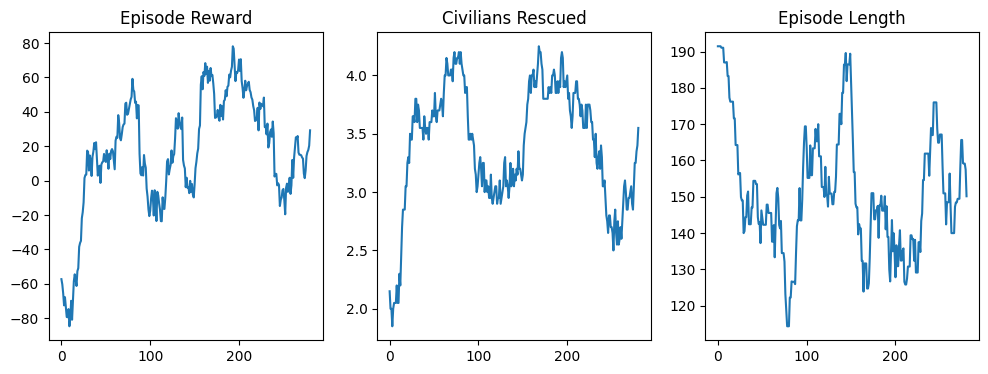

In [ ]:
#run v2
env_v2 = HeteroDisasterEnv_V2()
history, responder_agent, vehicle_agent = train_iql(env_v2, episodes=300)
plot_results(history)



In [ ]:
# for comparison
env_v1 = HeteroDisasterEnv()
history_v1 = train_iql(env_v1, episodes=300)


Episode 0 | Reward -9.00 | Rescued 2
Episode 50 | Reward 144.42 | Rescued 5
Episode 100 | Reward 41.00 | Rescued 4
Episode 150 | Reward 36.00 | Rescued 4
Episode 200 | Reward 149.42 | Rescued 5
Episode 250 | Reward -114.00 | Rescued 2


Episode 0 | Reward -239.00 | Rescued 1
Episode 50 | Reward -129.00 | Rescued 1
Episode 100 | Reward -89.00 | Rescued 1
Episode 150 | Reward 88.28 | Rescued 5
Episode 200 | Reward 88.44 | Rescued 5
Episode 250 | Reward 16.00 | Rescued 4


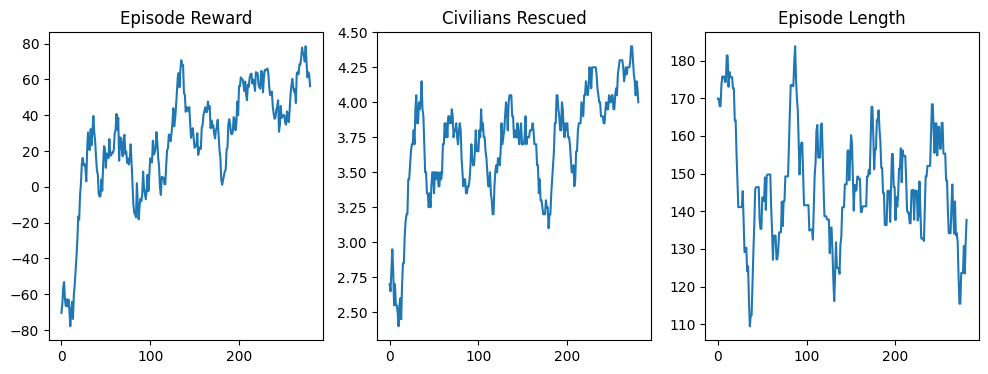

In [ ]:
#heterogeneity ablation: no vehicle agents
env_ablation = HeteroDisasterEnv_V2(
    grid_size=10,
    n_responders=2,
    n_vehicles=0,   # <-- KEY ABLATION
    n_civilians=5,
    hazard_prob=0.05
)

history_ablation, _, _ = train_iql(env_ablation, episodes=300)
plot_results(history_ablation)


ROLLOUT VISUALISATION

In [ ]:
#render and save frames- utility
import os
import numpy as np
import matplotlib.pyplot as plt

def render_and_save(env, step, save_dir="rollout_frames"):
    os.makedirs(save_dir, exist_ok=True)

    grid = np.zeros((env.grid_size, env.grid_size))

    for o in env.obstacles:
        grid[o] = 1          # obstacle
    for c in env.civilians:
        grid[c[0], c[1]] = 2 # civilian

    grid[env.shelter] = 3    # shelter

    for a in env.agents:
        grid[a[0], a[1]] = 4 # agents

    plt.figure(figsize=(4,4))
    plt.imshow(grid)
    plt.title(f"Step {step}")
    plt.axis("off")
    plt.savefig(f"{save_dir}/frame_{step:03d}.png", bbox_inches="tight")
    plt.close()


In [ ]:
#deterministic rollout function- no learning needed here
def rollout_trained_policy(env, responder_agent, vehicle_agent, max_steps=200):
    obs = env.reset()
    done = False
    step = 0

    # save initial state
    render_and_save(env, step)

    while not done and step < max_steps:
        actions = []

        for i in range(env.n_agents):
            if env.agent_types[i] == "responder":
                state = responder_agent.get_state(obs[i], env.carrying[i])
                action = int(np.argmax(responder_agent.q[state]))
            else:
                state = vehicle_agent.get_state(obs[i], env.carrying[i])
                action = int(np.argmax(vehicle_agent.q[state]))

            actions.append(action)

        obs, rewards, done = env.step(actions)
        step += 1

        # save every 10 steps + final
        if step % 10 == 0 or done:
            render_and_save(env, step)

    print("Rollout finished.")
    print("Steps taken:", step)
    print("Civilians remaining:", len(env.civilians))


In [ ]:
#run rollout
env_rollout = HeteroDisasterEnv_V2(hazard_prob=0.05)
rollout_trained_policy(env_rollout, responder_agent, vehicle_agent)


Rollout finished.
Steps taken: 200
Civilians remaining: 5


In [ ]:
print("rgvcdwdff")

rgvcdwdff
